# Challenge: Telecom X - Predicción de Cancelación
Se ha sido promovido después de tu excelente desempeño en el análisis exploratorio de la cancelación de clientes en Telecom X. El nuevo objetivo es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios ya que la empresa quiere anticiparse al problema de la cancelación.


> **Desafío:** Preparar los datos para el modelado, incluyendo el tratamiento de valores faltantes, la codificación de variables categóricas y la normalización de los datos numéricos. Realizar un análisis de correlación y selección de variables relevantes para identificar los factores más influyentes. Entrenar dos o más modelos de clasificación y evaluar su rendimiento mediante métricas adecuadas. Interpretar los resultados, destacando la importancia relativa de cada variable en la predicción, y elaborar una conclusión estratégica que señale los principales factores que influyen en la cancelación, proporcionando información útil para la toma de decisiones.

## 🛠️ Preparación de los Datos

**1. Carga de Datos Tratados:**

Importar el dataset que se preparó en la fase anterior. Este archivo ya contiene las columnas relevantes y las correcciones de formato necesarias.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv('/content/TelecomX_Data_Procesado.csv')
df.head()

,customerID,Evasión,Género,Adulto mayor,Tiene pareja,Dependientes,Meses activo,Servicio telefonico,Lineas múltiples,Servicio de internet,...,Protección dispositivo,Soporte técnico,Televisión por cable,Streaming películas,Tipo contrato,Factura digital,Forma de pago,Cargo mensual,Cargo total,Cargo diario
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


**2. Revisión de datos y eliminación las columnas que no aportan valor**

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customerID              7043 non-null   object 
 1   Evasión                 7043 non-null   int64  
 2   Género                  7043 non-null   object 
 3   Adulto mayor            7043 non-null   int64  
 4   Tiene pareja            7043 non-null   int64  
 5   Dependientes            7043 non-null   int64  
 6   Meses activo            7043 non-null   int64  
 7   Servicio telefonico     7043 non-null   int64  
 8   Lineas múltiples        7043 non-null   object 
 9   Servicio de internet    7043 non-null   object 
 10  Seguridad online        7043 non-null   object 
 11  Respaldo online         7043 non-null   object 
 12  Protección dispositivo  7043 non-null   object 
 13  Soporte técnico         7043 non-null   object 
 14  Televisión por cable    7043 non-null   

In [39]:
df.shape

(7043, 22)

In [40]:
variables_numericas = ['Meses activo', 'Cargo mensual', 'Cargo diario', 'Cargo total']
df[variables_numericas].describe()

,Meses activo,Cargo mensual,Cargo diario,Cargo total
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2.158675,2279.734304
std,24.559481,30.090047,1.003088,2266.794470
min,0.000000,18.250000,0.610000,0.000000
25%,9.000000,35.500000,1.180000,398.550000
50%,29.000000,70.350000,2.340000,1394.550000
75%,55.000000,89.850000,2.990000,3786.600000
max,72.000000,118.750000,3.960000,8684.800000


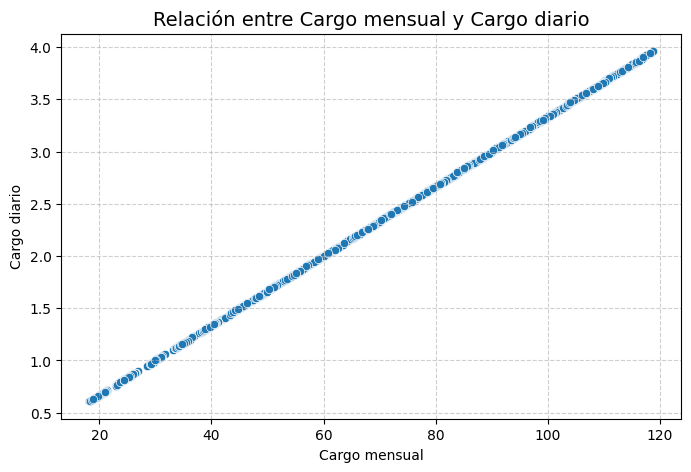

In [41]:
#Correlación entre las variables cargo diario y cargo mensual

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Cargo mensual', y='Cargo diario')
plt.title('Relación entre Cargo mensual y Cargo diario', fontsize=14)
plt.xlabel('Cargo mensual')
plt.ylabel('Cargo diario')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

>Se presenta una linealidad perfecta entre "Cargo diario" y "Cargo mensual"

Mantener ambas variables introduciría redundancia y podría afectar la estabilidad de los coeficientes en modelos lineales

In [42]:
df = df.drop(columns=['customerID', 'Cargo diario'])
df.columns.tolist()

['Evasión',
 'Género',
 'Adulto mayor',
 'Tiene pareja',
 'Dependientes',
 'Meses activo',
 'Servicio telefonico',
 'Lineas múltiples',
 'Servicio de internet',
 'Seguridad online',
 'Respaldo online',
 'Protección dispositivo',
 'Soporte técnico',
 'Televisión por cable',
 'Streaming películas',
 'Tipo contrato',
 'Factura digital',
 'Forma de pago',
 'Cargo mensual',
 'Cargo total']

**3. Transformación de las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning.**

Variable objetivo y explicativas

In [43]:
X = df.drop('Evasión', axis=1)
y = df['Evasión']

In [44]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

columnas_categoricas = [
    'Género', 'Adulto mayor', 'Tiene pareja', 'Dependientes',
    'Servicio telefonico', 'Lineas múltiples', 'Servicio de internet',
    'Seguridad online', 'Respaldo online', 'Protección dispositivo',
    'Soporte técnico', 'Televisión por cable', 'Streaming películas',
    'Tipo contrato', 'Factura digital', 'Forma de pago'
]

one_hot = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), columnas_categoricas),
    remainder='passthrough',
    sparse_threshold=0
)

X_transformado = one_hot.fit_transform(X)

X = pd.DataFrame(X_transformado, columns=one_hot.get_feature_names_out())

In [47]:
X.head(10)

,onehotencoder__Género_Male,onehotencoder__Adulto mayor_1,onehotencoder__Tiene pareja_1,onehotencoder__Dependientes_1,onehotencoder__Servicio telefonico_1,onehotencoder__Lineas múltiples_No,onehotencoder__Lineas múltiples_No phone service,onehotencoder__Lineas múltiples_Yes,onehotencoder__Servicio de internet_DSL,onehotencoder__Servicio de internet_Fiber optic,...,onehotencoder__Tipo contrato_One year,onehotencoder__Tipo contrato_Two year,onehotencoder__Factura digital_1,onehotencoder__Forma de pago_Bank transfer (automatic),onehotencoder__Forma de pago_Credit card (automatic),onehotencoder__Forma de pago_Electronic check,onehotencoder__Forma de pago_Mailed check,remainder__Meses activo,remainder__Cargo mensual,remainder__Cargo total
0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,65.60,593.30
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,9.0,59.90,542.40
2,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.0,73.90,280.85
3,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,13.0,98.00,1237.85
4,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,3.0,83.90,267.40
5,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,9.0,69.40,571.45
6,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,71.0,109.70,7904.25
7,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,63.0,84.65,5377.80
8,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,7.0,48.20,340.35
9,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,65.0,90.45,5957.90


In [46]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y= LabelEncoder().fit_transform(y)
y

array([0, 0, 1, ..., 0, 0, 0])

**4. Verificación de la Proporción de Cancelación**

In [52]:
print("Frecuencia absoluta de Evasión:")
print(df['Evasión'].value_counts())

print("\nFrecuencia relativa (Porcentaje):")
print(df['Evasión'].value_counts(normalize=True).round(4) * 100)

Frecuencia absoluta de Evasión:
Evasión
0    5174
1    1869
Name: count, dtype: int64

Frecuencia relativa (Porcentaje):
Evasión
0    73.46
1    26.54
Name: proportion, dtype: float64


In [62]:
def proporcion_cancelacion():
  sns.set_theme(style="whitegrid")

  plt.figure(figsize=(8, 5))

  # Usamos 'hue' para la misma variable para que cada barra tenga su color y leyenda
  # La paleta 'viridis' o 'magma' le da ese toque profesional que usas en clase
  ax = sns.countplot(data=df, x='Evasión', hue='Evasión', palette='Set2', legend=False)

  plt.title('Distribución de clientes según la evasión', fontsize=14)
  plt.xlabel('Estado del Cliente (0 = Permaneció, 1 = Canceló)', fontsize=12)
  plt.ylabel('Cantidad de clientes', fontsize=12)
  plt.ylim(0,6000)

  for p in ax.patches:
      ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
  sns.despine()
  return plt

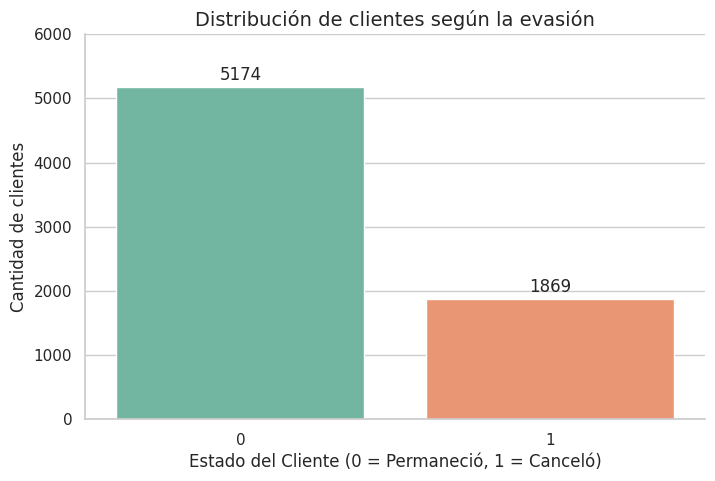

In [63]:
proporcion_cancelacion().show()

## 🎯 Correlación y Selección de Variables

**Análisis de Correlación**

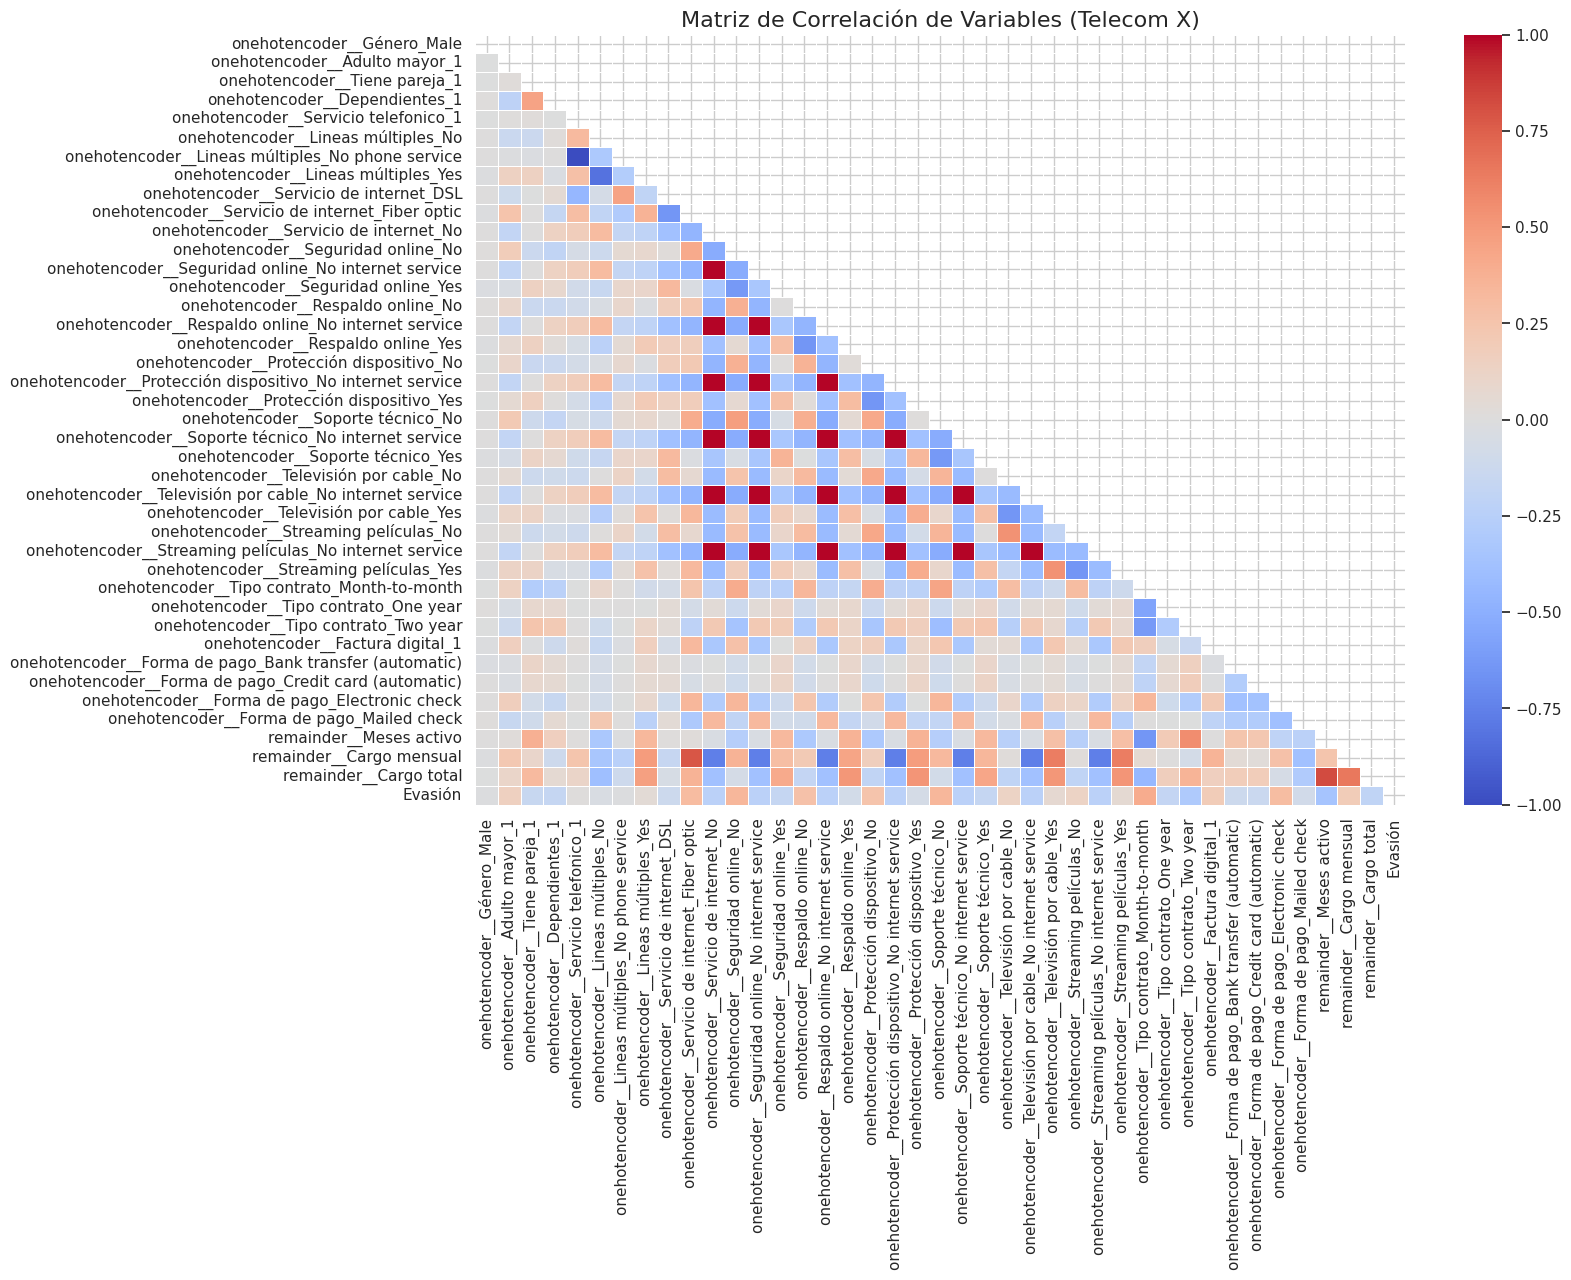

In [66]:
# 1. Creamos un DataFrame que incluya tanto X como y para ver la relación con la meta
df_analisis = X.copy()
df_analisis['Evasión'] = y

# 2. Calculamos la matriz de correlación
corr_matrix = df_analisis.corr()

# 3. Graficamos el Heatmap
plt.figure(figsize=(15, 10))
# Usamos una máscara para ver solo la mitad inferior (evita duplicados)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables (Telecom X)', fontsize=16)
plt.show()

In [69]:
# Ver solo la correlación con la variable objetivo 'Evasión'
correlacion_target = corr_matrix['Evasión'].sort_values(ascending=False)

print("Variables con mayor correlación con la evasión:")
print(correlacion_target.head(10)) # Las que más provocan que se vayan
print("---------------------------------------------------------------")

print("\nVariables que más evitan la evasión:")
print(correlacion_target.tail(10)) # Las que más retienen al cliente

Variables con mayor correlación con la evasión:
Evasión                                            1.000000
onehotencoder__Tipo contrato_Month-to-month        0.405103
onehotencoder__Seguridad online_No                 0.342637
onehotencoder__Soporte técnico_No                  0.337281
onehotencoder__Servicio de internet_Fiber optic    0.308020
onehotencoder__Forma de pago_Electronic check      0.301919
onehotencoder__Respaldo online_No                  0.268005
onehotencoder__Protección dispositivo_No           0.252481
remainder__Cargo mensual                           0.193356
onehotencoder__Factura digital_1                   0.191825
Name: Evasión, dtype: float64
---------------------------------------------------------------

Variables que más evitan la evasión:
remainder__Cargo total                                      -0.198324
onehotencoder__Servicio de internet_No                      -0.227890
onehotencoder__Televisión por cable_No internet service     -0.227890
onehotenco

**Análisis Dirigido**